In [1]:
import jax.numpy as jnp
import numpy as np 

from sklearn.datasets import fetch_20newsgroups

import matplotlib.pyplot as plt
import seaborn as sns

from cartm.model import ContextTopicModel
#from cartm.attentive_model import AttentiveTopicModel
#from cartm.improved_model import AttentiveTopicModel
from cartm.attentive_model import MatveyAttentiveTopicModel
from cartm.preprocessing import DatasetPreprocessor

In [9]:
from sklearn.datasets import fetch_20newsgroups

This example will guide you through the basic interaction with the model.

## Data preprocessing

First, let's download a sample dataset and preprocess it with `DatasetPreprocessor`.

In [10]:
data = fetch_20newsgroups(data_home='../data/', subset='all').data
print(f'Total number of documents in corpus: {len(data)}')
print(f'Total number of words in corpus: {sum([len(doc.split(" ")) for doc in data])}')

Total number of documents in corpus: 18846
Total number of words in corpus: 5937230


In [11]:
data = data[:400]

In [ ]:
#for line in data:
#    print(line)

In [36]:
with open('./data/test_data.txt') as f:
    data = f.readlines()
print(f'Total number of documents in corpus: {len(data)}')
print(f'Total number of words in corpus: {sum([len(doc.split(" ")) for doc in data])}')

Total number of documents in corpus: 4
Total number of words in corpus: 34


In [12]:
preprocessor = DatasetPreprocessor(stopwords=[], min_word_len=0)
tokenized_data, document_bounds = preprocessor.fit_transform(data)
print(f'Total number of document boundaries in preprocessed corpus: {len(document_bounds)}')
print(f'Total number of tokenized words in preprocessed corpus: {len(tokenized_data)}')

Total number of document boundaries in preprocessed corpus: 401
Total number of tokenized words in preprocessed corpus: 96398


The `DatasetPreprocessor` class handles the filtering and tokenizing of the raw data. Its method `fit_transform` learns the vocabulary of the passed corpus of documents and returns tokenized words from corpus as the first return value, and document bounds as the second return value.

By default, `DatasetPreprocessor` removes stopwords, digits and special characters, therefore the total number of tokenized words is less than the number of words in raw corpus. Document boundaries are at the beginning and ending of the document, therefore the number of boundaries is [number_of_documents] + 1.

The returned values from `fit_transform` have jax.numpy.ndarray type, so you can work with them like a normal arrays.

In [13]:
print(f'Number of unique words in the preprocessed corpus: {jnp.max(tokenized_data)}')

Number of unique words in the preprocessed corpus: 10021


### Accessing vocabulary

You can also access mapping of words to tokens after fitting the preprocessor with data.

In [14]:
vocabulary = preprocessor.vocabulary

for i, (word, token) in enumerate(vocabulary.items()):
    print(f'{word}: {token}')
    if i == 10:
        break

reverse_vocab = {value: key for key, value in vocabulary.items()}
#[reverse_vocab[t] for t in tokenized_data.tolist()]

unb: 0
nova: 1
repres: 2
pioneer: 3
passov: 4
sdcn: 5
includ: 6
sherrin: 7
sublimin: 8
goug: 9
neither: 10


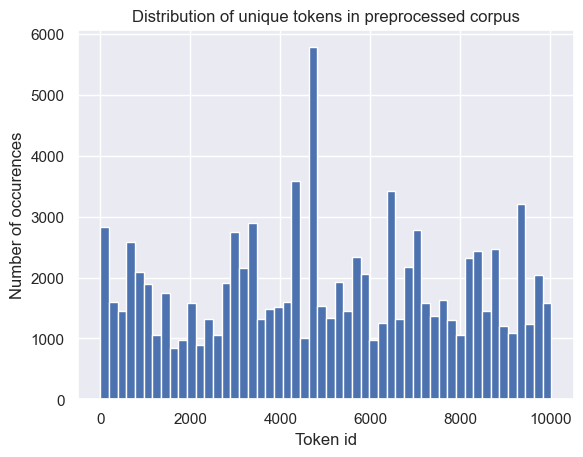

In [15]:
sns.set_theme()

#plt.hist(tokenized_data, bins=100)
plt.hist(tokenized_data, bins='auto')

plt.xlabel('Token id')
plt.ylabel('Number of occurences')
plt.title('Distribution of unique tokens in preprocessed corpus')
#plt.yscale('log')
plt.show()

[('the', np.int64(4317)), ('to', np.int64(2112)), ('of', np.int64(1959)), ('a', np.int64(1845)), ('and', np.int64(1616)), ('i', np.int64(1567)), ('in', np.int64(1448)), ('is', np.int64(1262)), ('that', np.int64(1138)), ('it', np.int64(995))]
96398


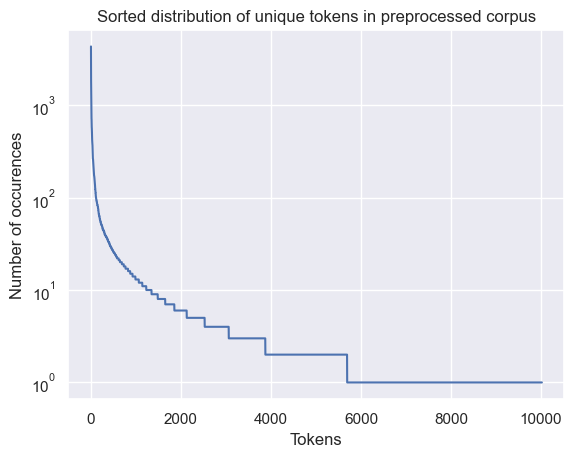

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data
data = tokenized_data
tokens, counts = np.unique(tokenized_data, return_counts=True)
sorted_indices = np.argsort(counts)[::-1]
sorted_counts = counts[sorted_indices]
sorted_tokens = tokens[sorted_indices]

print([(reverse_vocab[sorted_tokens[i]], sorted_counts[i]) for i in range(10)])
print(sum(sorted_counts))

plt.plot(sorted_counts)
plt.yscale('log')
plt.xlabel('Tokens')
plt.ylabel('Number of occurences')
plt.title('Sorted distribution of unique tokens in preprocessed corpus')
plt.show()

## Model training

Having the data preprocessed with `DatasetPreprocessor`, we can fit out model pretty straighforwardly.

Please note that calling `fit` method multiple times in one model will discard all results of the previous training.

In [17]:
%load_ext autoreload
%autoreload 2

In [ ]:
topic_model = MatveyAttentiveTopicModel(
    vocab_size=len(preprocessor.vocabulary),
    ctx_len=10,
    n_topics=10
)

topic_model.fit(
    data=tokenized_data,
    ctx_bounds=document_bounds,
    verbose=2,
    seed=42,
)

In [20]:
phi = topic_model.phi

The model training stops because the update diff norm becomes too low. This means that the model has converged. You can modify the convergence threshold and max number of iterations.

You can also modify number of topics and other parameters of the model. Refer to the `fit` funciton docs for more info about model training.

## Analysis

After the model is fitted, you can access its parameters and analyse them.

In [21]:
phi_wt = topic_model.phi  # p(w|t)
n_t = topic_model.n_t  # denormalized distribution of topics
print(f'phi matrix type: {type(phi_wt)}, shape: {phi_wt.shape}')
print(f'n_t array type: {type(n_t)}, shape: {n_t.shape}')

phi matrix type: <class 'jaxlib._jax.ArrayImpl'>, shape: (10022, 10)
n_t array type: <class 'jaxlib._jax.ArrayImpl'>, shape: (10,)


### Plot a histogram of a distribution of topics in corpus:

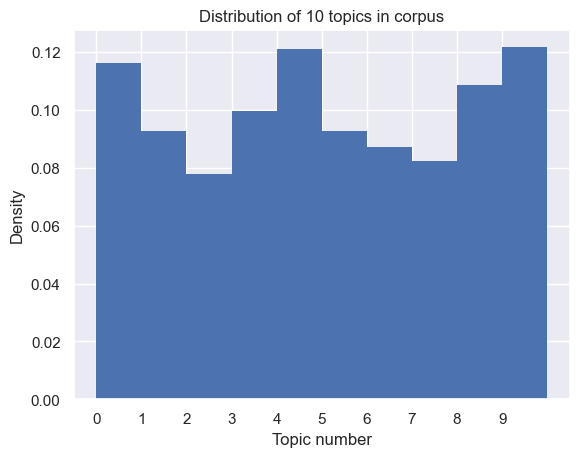

In [22]:
plt.stairs(n_t / n_t.sum(), range(len(n_t) + 1), fill=True)

plt.xticks(range(len(n_t)))
plt.xlabel('Topic number')
plt.ylabel('Density')
plt.title('Distribution of 10 topics in corpus')
plt.show()

### Print top-10 words from each topic:

In [23]:
# find top-10 words with the biggest probability p(w|t) for each topic t
topk = jnp.argsort(phi_wt, axis=0, descending=True)[:20, :].T

# create mapping token -> word from existing mapping word -> token (vocabulary)
reverse_vocab = {value: key for key, value in vocabulary.items()}

for topic_idx, t in enumerate(topk):
    print(f'Topic {topic_idx + 1}:', '\t'.join([reverse_vocab[int(idx)] for idx in t]))
    print()

Topic 1: to	in	for	you	if	my	articl	were	could	go	anyon	problem	david	run	want	mail	news	det	find	research

Topic 2: and	not	subject	or	re	when	more	look	day	uk	may	thank	two	key	our	much	number	under	reason	base

Topic 3: s	com	do	all	who	some	how	their	think	o	work	state	those	said	john	r	b	befor	de	point

Topic 4: is	be	as	wa	they	so	will	about	get	just	well	good	god	most	bit	call	come	question	into	better

Topic 5: the	he	would	m	peopl	than	up	onli	also	new	now	then	here	right	name	anoth	opinion	got	tell	human

Topic 6: it	with	thi	can	by	we	me	host	like	make	d	window	thing	us	help	even	mean	over	p	v

Topic 7: on	t	an	one	no	your	which	know	nntp	x	law	these	becaus	system	did	where	first	drive	tri	card

Topic 8: edu	line	there	ani	ca	don	other	had	been	hi	year	cs	e	comput	veri	world	after	u	christian	whi

Topic 9: i	that	are	organ	write	use	c	them	say	time	apr	way	should	ac	see	repli	mani	need	ve	seem

Topic 10: of	a	from	have	but	at	what	post	ha	univers	out	doe	distribut	such	own	i

In [11]:
from jax import jit

@jit
def entropy_renyi(matrix, power):
    entropies = jnp.sum(matrix ** power, axis=1)
    #return entropies    
    return entropies / jnp.max(entropies)

In [33]:
jnp.sum(phi_wt ** 1.5, axis=1).shape

(10022,)

In [12]:
entropys = [(s, entropy_renyi(phi_wt, power=s)) for s in np.linspace(1.1, 1.9, num=9)]
print(f"{entropys=}")
cum_entropys = []


NameError: name 'phi_wt' is not defined

In [52]:
print(f"{phi_wt[0]=}")
print(sum([p_t**1.1 for p_t in phi_wt[0]]))
print(f"{reverse_vocab[0]=}")
print(f"{phi_wt[1]=}")
print(f"{reverse_vocab[1]=}")
print(sum([p_t**1.1 for p_t in phi_wt[1]]))
entropys[0][1][:2]

phi_wt[0]=Array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.00037488, 0.        , 0.        ],      dtype=float32)
0.00017032788
reverse_vocab[0]='unb'
phi_wt[1]=Array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.00085578, 0.        , 0.        ],      dtype=float32)
reverse_vocab[1]='nova'
0.00042227953


Array([0.00451586, 0.01119579], dtype=float32)

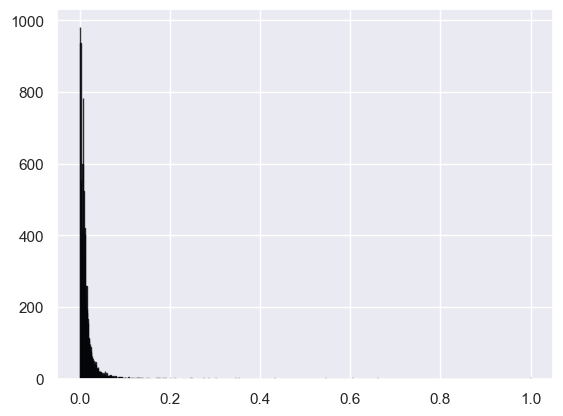

In [56]:
counts, bin_edges, _ = plt.hist(
    entropys[0][1], 
    bins=1000, 
    range=(0, 1),  # фиксированный диапазон
    density=False,
    color='b', 
    edgecolor='black',
    alpha=0.8,
    label='Распределение'
)


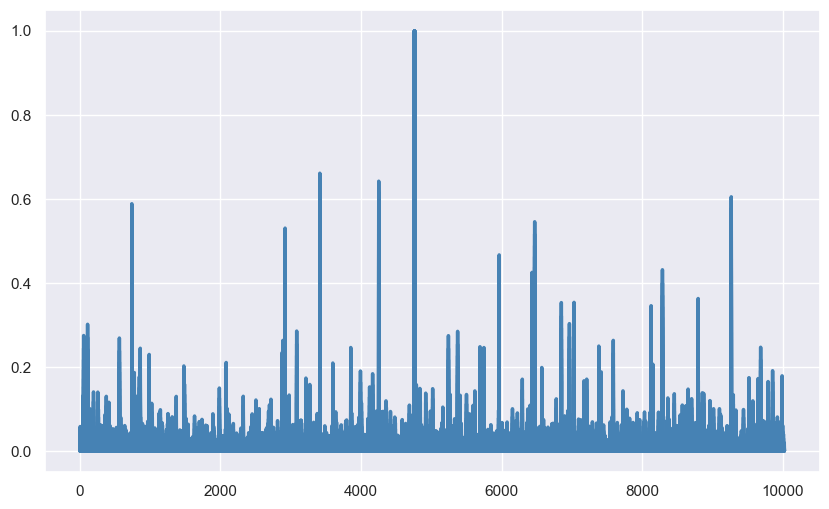

In [57]:

plt.figure(figsize=(10, 6))
for s, entropy in entropys:
    plt.plot(entropy, 
        linestyle='-', linewidth=2.5, markersize=8,
        color='steelblue', markerfacecolor='white', markeredgecolor='steelblue')


In [15]:
def plot_distribution_advanced(data, n_bins=20, figsize=(12, 5), 
                              plot_type='all', bandwidth=None):
    """
    Расширенная визуализация распределения.
    
    Args:
        data: 1D массив чисел в [0, 1]
        n_bins: количество бинов для гистограммы
        figsize: размер фигуры
        plot_type: 'hist' | 'kde' | 'ecdf' | 'all'
        bandwidth: ширина окна для KDE (по умолчанию автоматический выбор)
    
    Returns:
        dict с данными для каждого типа графика
    """
    #data = np.asarray(data)
    #n = len(data)
    
    results = {}
    
    # === ГИСТОГРАММА ===
    if plot_type in ['hist', 'all']:
        fig, ax = plt.subplots(figsize=figsize)
        counts, bin_edges, _ = ax.hist(
            data, bins=n_bins, range=(0, 1), density=True,
            color='skyblue', edgecolor='black', alpha=0.7, label='Гистограмма'
        )
        ax.set_xlabel('Значение', fontsize=11)
        ax.set_ylabel('Плотность', fontsize=11)
        ax.set_title('Гистограмма распределения', fontsize=13, pad=15)
        ax.grid(True, alpha=0.3, linestyle='--', axis='y')
        ax.set_xlim(0, 1)
        ax.legend()
        plt.tight_layout()
        plt.show()
        
        results['hist'] = {'counts': counts, 'bin_edges': bin_edges}
    
    # === KDE (ядерная оценка плотности) ===
    if plot_type in ['kde', 'all']:
        from scipy.stats import gaussian_kde
        
        # Автоматический bandwidth, если не задан
        if bandwidth is None:
            bandwidth = 1.06 * data.std() * n ** (-1/5)  # правило Сильвермана
        
        # Оценка плотности
        x_eval = np.linspace(0, 1, 200)
        kde = gaussian_kde(data, bw_method=bandwidth / data.std() if data.std() > 0 else 1.0)
        # Обрезаем выбросы KDE за пределами [0, 1]
        density = kde(x_eval)
        density = np.where((x_eval >= 0) & (x_eval <= 1), density, 0)
        
        plt.figure(figsize=figsize)
        plt.plot(x_eval, density, linewidth=2.5, color='darkorange', label='KDE')
        plt.fill_between(x_eval, density, alpha=0.2, color='darkorange')
        plt.xlabel('Значение', fontsize=11)
        plt.ylabel('Плотность', fontsize=11)
        plt.title('Ядерная оценка плотности (KDE)', fontsize=13, pad=15)
        plt.grid(True, alpha=0.3, linestyle='--')
        plt.xlim(0, 1)
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        results['kde'] = {'x': x_eval, 'density': density}
    
    # === ECDF (эмпирическая функция распределения) ===
    if plot_type in ['ecdf', 'all']:
        n = len(data[0][1])
        
        ecdf = np.arange(1, n + 1) / n
        
        plt.figure(figsize=figsize)
        for i in range(len(data)):
        #for i in range(1):
            sorted_data = np.sort(np.asarray(data[i][1]))
            plt.plot(sorted_data, ecdf, linewidth=2, color='darkgreen', label='ECDF')
        plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Медиана')
        plt.axvline(x=np.median(sorted_data), color='red', linestyle=':', alpha=0.5)
        plt.xlabel('Значение', fontsize=11)
        plt.ylabel('Накопленная доля', fontsize=11)
        plt.title('Эмпирическая функция распределения (ECDF)', fontsize=13, pad=15)
        plt.grid(True, alpha=0.3, linestyle='--')
        plt.xlim(0, 1)
        plt.ylim(0, 1.05)
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        results['ecdf'] = {'x': sorted_data, 'ecdf': ecdf}
    
    # Статистика
    #print(f"📊 Статистика данных (n={n})")
    #print(f"   Мин: {data.min():.4f}, Макс: {data.max():.4f}")
    #print(f"   Среднее: {data.mean():.4f}, Медиана: {np.median(data):.4f}")
    #print(f"   Стд. отклонение: {data.std():.4f}")
    #print(f"   Квантили: 25%={np.percentile(data, 25):.4f}, "
    #      f"75%={np.percentile(data, 75):.4f}")
    
    #return results

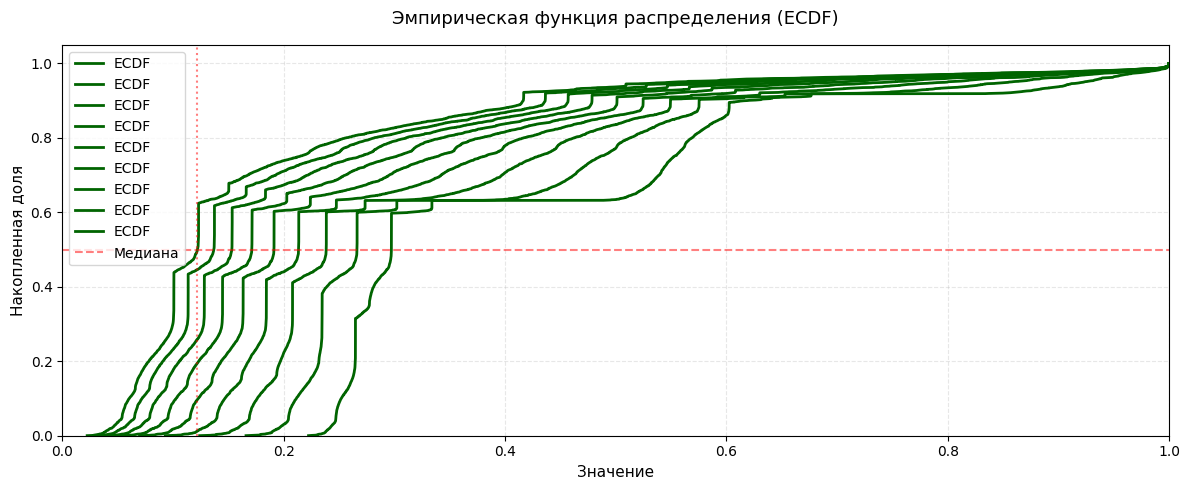

In [21]:
# Разные типы распределений для теста
data_uniform = np.random.uniform(0, 1, 1000)      # равномерное
data_beta = np.random.beta(2, 5, 1000)            # скошено вправо
data_bimodal = np.concatenate([
    np.random.beta(2, 2, 500) * 0.4,              # левый пик
    np.random.beta(2, 2, 500) * 0.4 + 0.6         # правый пик
])

# Построение всех типов графиков
plot_distribution_advanced(entropys, plot_type='ecdf')


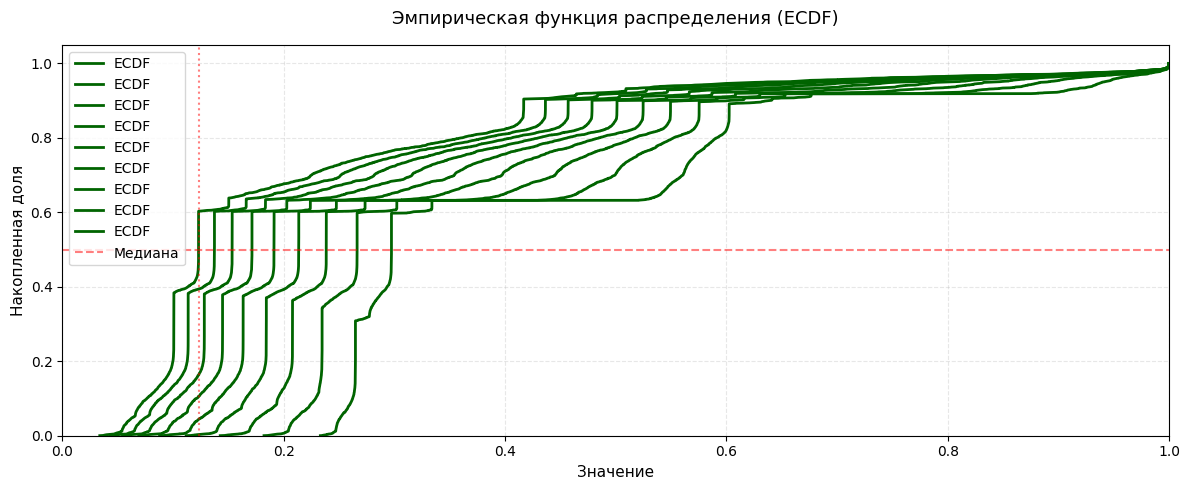

In [25]:
# Построение всех типов графиков
plot_distribution_advanced(entropys, plot_type='ecdf')

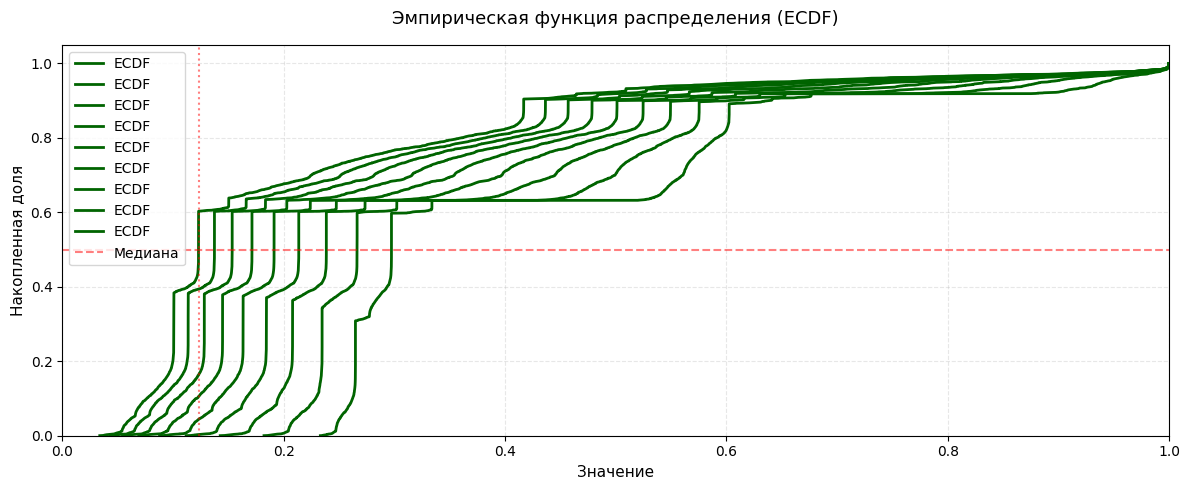

In [16]:
# Построение всех типов графиков
plot_distribution_advanced(entropys, plot_type='ecdf')

In [66]:
vocabulary['the']

6470

In [67]:
phi_wt[vocabulary['the']]

Array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.02927835, 0.        ],      dtype=float32)

In [68]:
phi_wt[:10]

Array([[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 3.7488341e-04,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 8.5578312e-04,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 2.3043703e-03],
       [6.4324460e-04, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        4.0170100e-05, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        4.0313233e-05, 0.0000000e+00, 0.0000000e+00, 0.00

In [4]:
import json

# Open the file in read mode ('r')
with open('../../vocab Stanislavo.json', 'r') as file:
    # Use json.load to deserialize the file content into a dictionary
    my_dict = json.load(file)


In [5]:
list(my_dict.items())[:50]

[('aaa', 0),
 ('abacu', 1),
 ('abandon', 2),
 ('abil', 3),
 ('abl', 4),
 ('abolish', 5),
 ('abort', 6),
 ('abroad', 7),
 ('absenc', 8),
 ('absolut', 9),
 ('absorb', 10),
 ('academi', 11),
 ('accept', 12),
 ('access', 13),
 ('accident', 14),
 ('acclaim', 15),
 ('accompani', 16),
 ('accord', 17),
 ('account', 18),
 ('accumul', 19),
 ('accur', 20),
 ('accus', 21),
 ('achiev', 22),
 ('acknowledg', 23),
 ('acoust', 24),
 ('acpo', 25),
 ('acquir', 26),
 ('acquisit', 27),
 ('acr', 28),
 ('acrobat', 29),
 ('across', 30),
 ('act', 31),
 ('action', 32),
 ('activ', 33),
 ('activist', 34),
 ('actor', 35),
 ('actress', 36),
 ('actual', 37),
 ('ad', 38),
 ('adag', 39),
 ('adam', 40),
 ('adapt', 41),
 ('adaptor', 42),
 ('add', 43),
 ('addit', 44),
 ('address', 45),
 ('adequ', 46),
 ('adjust', 47),
 ('administr', 48),
 ('admir', 49)]

In [6]:
my_dict['on']

2763

In [8]:
phi_exps = np.load('../phi Stanislavo.npy')

In [9]:
phi_exps[my_dict['on']]

array([2.2745907e-09, 2.1172409e-07, 2.0895700e-10, 2.2163506e-01,
       1.1046797e-01], dtype=float32)

In [13]:
entropys = [(s, entropy_renyi(phi_exps, power=s)) for s in np.linspace(1.1, 1.9, num=9)]
print(f"{entropys=}")

E0425 14:19:31.991896   11982 cuda_executor.cc:1743] Could not get kernel mode driver version: [INVALID_ARGUMENT: Version does not match the format X.Y.Z]
E0425 14:19:32.003158    6895 cuda_executor.cc:1743] Could not get kernel mode driver version: [INVALID_ARGUMENT: Version does not match the format X.Y.Z]


entropys=[(np.float64(1.1), Array([0.26489094, 0.24800219, 0.2856394 , ..., 0.26362553, 0.24752755,
       0.29328108], dtype=float32)), (np.float64(1.2000000000000002), Array([0.2347571 , 0.2061328 , 0.24650928, ..., 0.23283884, 0.20504546,
       0.25972554], dtype=float32)), (np.float64(1.3), Array([0.20805123, 0.17157917, 0.21337202, ..., 0.20582715, 0.16990034,
       0.23048294], dtype=float32)), (np.float64(1.4), Array([0.1843834 , 0.14299569, 0.18516774, ..., 0.18205002, 0.14081685,
       0.20483994], dtype=float32)), (np.float64(1.5), Array([0.16340803, 0.1193065 , 0.16105257, ..., 0.16107628, 0.11674294,
       0.18224883], dtype=float32)), (np.float64(1.6), Array([0.14481878, 0.09964286, 0.14034957, ..., 0.14255068, 0.09681021,
       0.1622778 ], dtype=float32)), (np.float64(1.7), Array([0.12834428, 0.08329864, 0.12251181, ..., 0.12617359, 0.08030181,
       0.14457826], dtype=float32)), (np.float64(1.7999999999999998), Array([0.1137439 , 0.0696971 , 0.10709391, ..., 0.111

In [15]:
phi_exps_5 = np.copy(phi_exps)

In [19]:
phi_exps.shape

(4393, 20)

In [22]:
phi_exps_20 = np.copy(phi_exps)

In [23]:
phi_exps = phi_exps_5